# Dataset audit — processed HeadHunter résumé corpus

Structured audit of the **same artifacts** used in BERT fine-tuning, fairness evaluation, and city-swap experiments:

| Artifact | Role |
|----------|------|
| `data/processed/train.csv`, `val.csv`, `test.csv` | `resume_text`, fine `label`, `city_group`, `gender`, `age_group` |
| `data/processed/label_to_supercategory_v1.csv` | Maps fine title → **9 supercategories** (`supercategory`) |

**Outputs:** tables → `notebooks/results/dataset_audit/` · figures → `figures/dataset_audit/`.

This notebook contains **no model training**; it only profiles data quality, imbalance, and spurious cues.

For **headless** execution (`jupyter nbconvert`, CI), set `MPLBACKEND=Agg` so matplotlib does not require a display.


In [1]:
from __future__ import annotations

import json
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy.stats import chi2_contingency

warnings.filterwarnings("ignore", category=UserWarning)

_cwd = Path.cwd().resolve()
if (_cwd / "data" / "processed").is_dir():
    REPO_ROOT = _cwd
elif (_cwd.parent / "data" / "processed").is_dir():
    REPO_ROOT = _cwd.parent
else:
    raise FileNotFoundError(
        "Expected `data/processed/` under the repository root. "
        "Run from `my-repository/` or `my-repository/notebooks/`."
    )

PROCESSED_DIR = REPO_ROOT / "data" / "processed"
RESULTS_DIR = REPO_ROOT / "notebooks" / "results" / "dataset_audit"
FIG_DIR = REPO_ROOT / "figures" / "dataset_audit"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="paper", font_scale=1.05)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["figure.figsize"] = (7, 4)


def cramers_v(table: pd.DataFrame) -> float:
    chi2, _, _, _ = chi2_contingency(table, correction=False)
    n = table.to_numpy().sum()
    if n == 0 or chi2 != chi2:
        return float("nan")
    r, k = table.shape
    phi2 = chi2 / n
    phi2corr = max(0.0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = min(kcorr - 1, rcorr - 1)
    if denom <= 0:
        return float("nan")
    return float(np.sqrt(phi2corr / denom))


def collapse_rare_categories(s: pd.Series, top_k: int, other: str = "other") -> pd.Series:
    top = set(s.value_counts().head(top_k).index)
    return s.where(s.isin(top), other=other)


def normalize_ws(t: str) -> str:
    return re.sub(r"\s+", " ", str(t).strip().lower())


TRAIN_CSV = PROCESSED_DIR / "train.csv"
VAL_CSV = PROCESSED_DIR / "val.csv"
TEST_CSV = PROCESSED_DIR / "test.csv"
LABEL_MAP_CSV = PROCESSED_DIR / "label_to_supercategory_v1.csv"

for p in (TRAIN_CSV, VAL_CSV, TEST_CSV, LABEL_MAP_CSV):
    if not p.is_file():
        raise FileNotFoundError(f"Missing pipeline artifact: {p}")

df_train = pd.read_csv(TRAIN_CSV)
df_val = pd.read_csv(VAL_CSV)
df_test = pd.read_csv(TEST_CSV)
mapping = pd.read_csv(LABEL_MAP_CSV)

expected = {"resume_text", "label", "city_group", "gender", "age_group"}
for name, df in [("train", df_train), ("val", df_val), ("test", df_test)]:
    miss = expected - set(df.columns)
    if miss:
        raise ValueError(f"{name} split missing columns: {miss}")

label_to_super = dict(zip(mapping["label"], mapping["supercategory"]))
for df in (df_train, df_val, df_test):
    df["supercategory"] = df["label"].map(label_to_super)

if df_train["supercategory"].isna().any():
    bad = df_train.loc[df_train["supercategory"].isna(), "label"].unique()[:10]
    raise ValueError(f"Labels without supercategory mapping (example): {bad}")

df_all = pd.concat(
    [
        df_train.assign(split="train"),
        df_val.assign(split="val"),
        df_test.assign(split="test"),
    ],
    ignore_index=True,
)

print("REPO_ROOT:", REPO_ROOT)
print("rows:", len(df_all), "| supercategories:", df_all["supercategory"].nunique(), "| fine labels:", df_all["label"].nunique())
display(df_all.head(2))


REPO_ROOT: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository
rows: 27550 | supercategories: 9 | fine labels: 125


,resume_text,label,city_group,gender,age_group,supercategory,split
0,Опыт работы 10 лет 6 месяцев Монтажник слабото...,монтажник слаботочных систем,Other,Male,26–35,technical_specialized,train
1,Опыт работы 12 лет 3 месяца Март 2007 — по нас...,инженер,Воронеж,Male,36–50,generic_it_ops,train


## 1. Schema, dtypes, and completeness


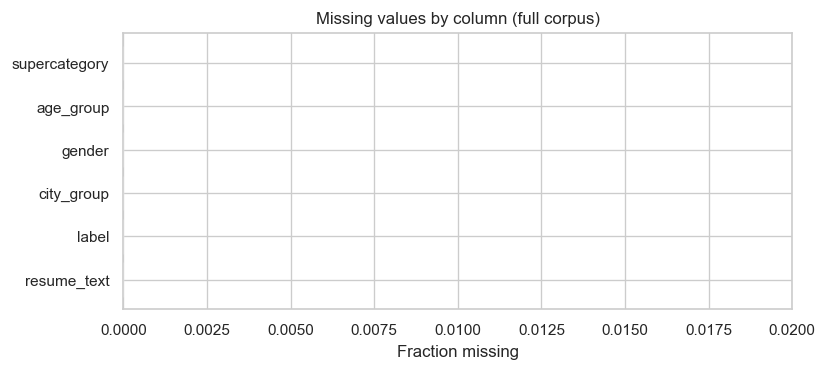

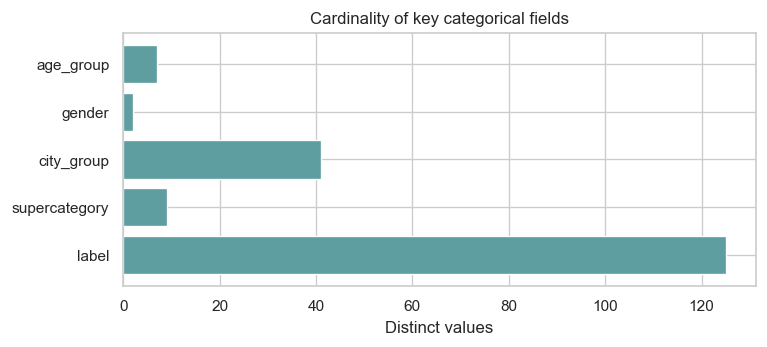

**Interpretation.** Pipeline columns are aligned across splits; maximum observed missingness is **0.000%**. Fine-label cardinality (**125** titles) is much larger than the 9 supercategories used for BERT heads. There is **no separate applicant-name column**; identifying strings, if present, appear only inside `resume_text`.

In [2]:
rows = []
for col in ["resume_text", "label", "city_group", "gender", "age_group", "supercategory"]:
    rows.append(
        {
            "column": col,
            "dtype": str(df_all[col].dtype),
            "null_count": int(df_all[col].isna().sum()),
            "null_frac": float(df_all[col].isna().mean()),
        }
    )
schema_df = pd.DataFrame(rows)
schema_df.to_csv(RESULTS_DIR / "01_schema_nulls.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(schema_df["column"], schema_df["null_frac"], color="steelblue")
ax.set_xlabel("Fraction missing")
ax.set_title("Missing values by column (full corpus)")
ax.set_xlim(0, max(0.02, schema_df["null_frac"].max() * 1.25))
fig.tight_layout()
fig.savefig(FIG_DIR / "01_schema_null_rates.png")
plt.show()

fig2, ax2 = plt.subplots(figsize=(6.5, 3))
counts = {c: int(df_all[c].nunique()) for c in ["label", "supercategory", "city_group", "gender", "age_group"]}
ax2.barh(list(counts.keys()), list(counts.values()), color="cadetblue")
ax2.set_xlabel("Distinct values")
ax2.set_title("Cardinality of key categorical fields")
fig2.tight_layout()
fig2.savefig(FIG_DIR / "01_column_cardinality.png")
plt.show()

mx = schema_df["null_frac"].max()
display(
    Markdown(
        f"**Interpretation.** Pipeline columns are aligned across splits; maximum observed missingness is **{mx:.3%}**. "
        f"Fine-label cardinality (**{counts['label']}** titles) is much larger than the 9 supercategories used for BERT heads. "
        f"There is **no separate applicant-name column**; identifying strings, if present, appear only inside `resume_text`."
    )
)


## 2. Split sizes


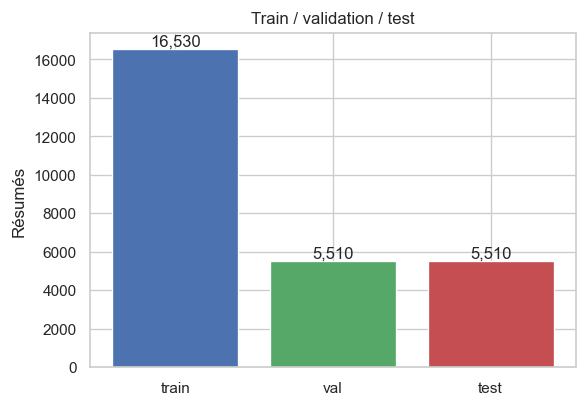

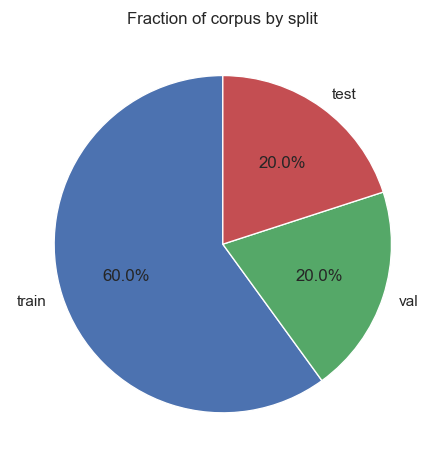

**Interpretation.** Standard three-way split: **16,530 / 5,510 / 5,510** (train/val/test). Equal val/test sizes match `24_finetuned_bert`, `40_fairness_and_error_analysis`, and city-swap notebooks.

In [3]:
split_counts = df_all["split"].value_counts().reindex(["train", "val", "test"])
pd.DataFrame({"split": split_counts.index, "n_rows": split_counts.values}).to_csv(
    RESULTS_DIR / "02_split_sizes.csv", index=False
)

fig, ax = plt.subplots(figsize=(5, 3.5))
cols = ["#4c72b0", "#55a868", "#c44e52"]
ax.bar(split_counts.index.astype(str), split_counts.values, color=cols)
for i, v in enumerate(split_counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Résumés")
ax.set_title("Train / validation / test")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_split_sizes.png")
plt.show()

split_props = split_counts / split_counts.sum()
fig2, ax2 = plt.subplots(figsize=(4, 4))
ax2.pie(split_props.values, labels=split_props.index, autopct="%1.1f%%", colors=cols, startangle=90)
ax2.set_title("Fraction of corpus by split")
fig2.tight_layout()
fig2.savefig(FIG_DIR / "02_split_proportions.png")
plt.show()

tr, va, te = int(split_counts.iloc[0]), int(split_counts.iloc[1]), int(split_counts.iloc[2])
display(
    Markdown(
        f"**Interpretation.** Standard three-way split: **{tr:,} / {va:,} / {te:,}** (train/val/test). "
        f"Equal val/test sizes match `24_finetuned_bert`, `40_fairness_and_error_analysis`, and city-swap notebooks."
    )
)


## 3. Label distribution (fine + supercategory)


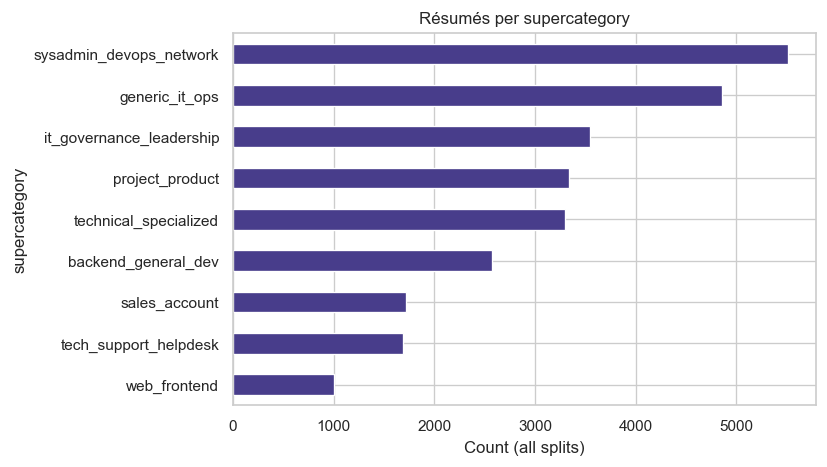

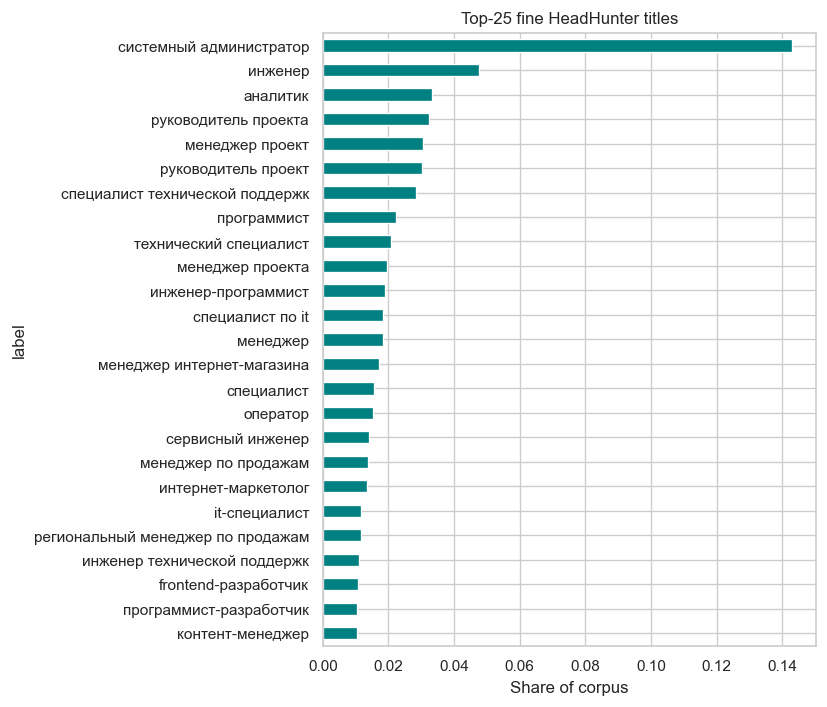

**Interpretation.** Supercategories are imbalanced (max/min ≈ **5.49**); fine labels are long-tail (max/min count ratio ≈ **77**). This supports class reweighting, focal loss, and GroupDRO experiments in the training notebooks.

In [4]:
sc_counts = df_all.groupby(["split", "supercategory"]).size().unstack(fill_value=0)
sc_counts.to_csv(RESULTS_DIR / "03_supercategory_counts_by_split.csv")

sc_total = df_all["supercategory"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
sc_total.plot(kind="barh", ax=ax, color="darkslateblue")
ax.set_xlabel("Count (all splits)")
ax.set_title("Résumés per supercategory")
fig.tight_layout()
fig.savefig(FIG_DIR / "03_supercategory_counts.png")
plt.show()

fine_frac = df_all["label"].value_counts(normalize=True)
fine_top = fine_frac.head(25)
pd.DataFrame({"label": fine_top.index, "fraction": fine_top.values}).to_csv(
    RESULTS_DIR / "04_top_fine_labels.csv", index=False
)

fig2, ax2 = plt.subplots(figsize=(7, 6))
fine_top.sort_values().plot(kind="barh", ax=ax2, color="teal")
ax2.set_xlabel("Share of corpus")
ax2.set_title("Top-25 fine HeadHunter titles")
fig2.tight_layout()
fig2.savefig(FIG_DIR / "04_top_fine_labels.png")
plt.show()

imb_sc = sc_total.max() / sc_total.min()
imb_fine = df_all["label"].value_counts().iloc[0] / df_all["label"].value_counts().iloc[-1]
display(
    Markdown(
        f"**Interpretation.** Supercategories are imbalanced (max/min ≈ **{imb_sc:.2f}**); fine labels are long-tail (max/min count ratio ≈ **{imb_fine:.0f}**). "
        f"This supports class reweighting, focal loss, and GroupDRO experiments in the training notebooks."
    )
)


## 4. Geography and sensitive attributes


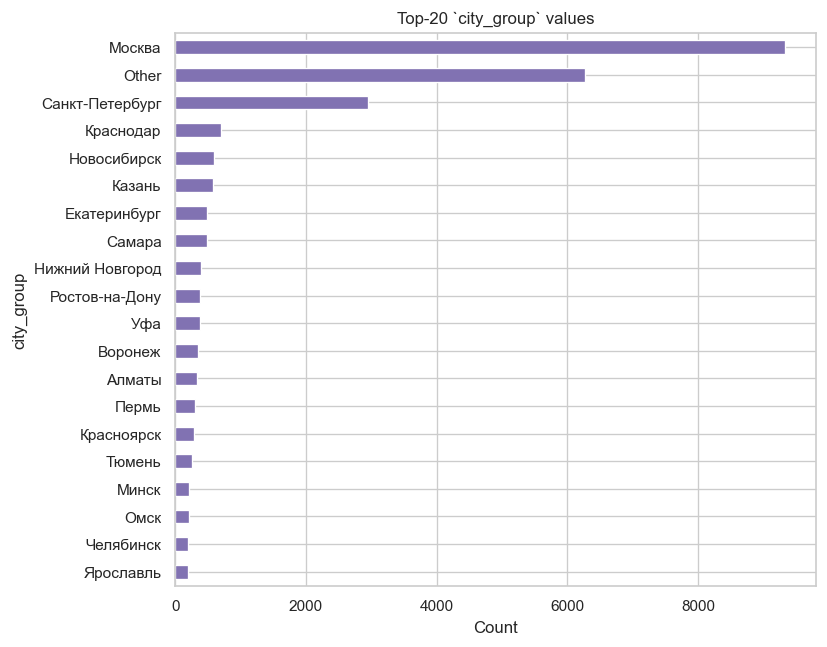

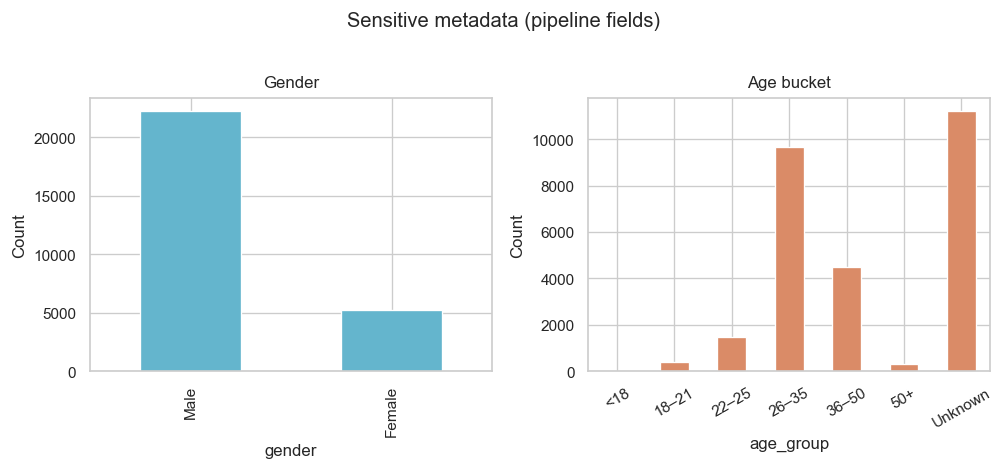

**Interpretation.** **Москва** ≈ **33.9%** of rows; remaining mass splits across regions and **Other**. Age is **Unknown** for **40.8%**—fairness slices on age should surface this bucket explicitly. There is **no separate country column**; non-RF hubs (e.g. Алматы) appear as city labels.

In [5]:
city_top = df_all["city_group"].value_counts().head(20)
pd.DataFrame({"city_group": city_top.index, "count": city_top.values}).to_csv(
    RESULTS_DIR / "05_top_city_groups.csv", index=False
)

fig, ax = plt.subplots(figsize=(7, 5.5))
city_top.sort_values().plot(kind="barh", ax=ax, color="#8172b2")
ax.set_xlabel("Count")
ax.set_title("Top-20 `city_group` values")
fig.tight_layout()
fig.savefig(FIG_DIR / "05_city_group_top20.png")
plt.show()

pd.crosstab(df_all["gender"], df_all["age_group"], normalize="index").to_csv(
    RESULTS_DIR / "06_gender_by_age_fractions.csv"
)

fig2, axes = plt.subplots(1, 2, figsize=(8.5, 3.8))
g_ord = df_all["gender"].value_counts().index.tolist()
df_all["gender"].value_counts().reindex(g_ord).plot(kind="bar", ax=axes[0], color="#64b5cd")
axes[0].set_title("Gender")
axes[0].set_ylabel("Count")

age_order = [b for b in ["<18", "18–21", "22–25", "26–35", "36–50", "50+", "Unknown"] if b in df_all["age_group"].unique()]
age_ct = df_all["age_group"].value_counts().reindex(age_order)
age_ct.plot(kind="bar", ax=axes[1], color="#da8b67")
axes[1].set_title("Age bucket")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=30)
fig2.suptitle("Sensitive metadata (pipeline fields)", y=1.02)
fig2.tight_layout()
fig2.savefig(FIG_DIR / "06_gender_age_counts.png")
plt.show()

unknown_age_frac = float((df_all["age_group"] == "Unknown").mean())
moscow_frac = float((df_all["city_group"] == "Москва").mean())
display(
    Markdown(
        f"**Interpretation.** **Москва** ≈ **{moscow_frac:.1%}** of rows; remaining mass splits across regions and **Other**. "
        f"Age is **Unknown** for **{unknown_age_frac:.1%}**—fairness slices on age should surface this bucket explicitly. "
        f"There is **no separate country column**; non-RF hubs (e.g. Алматы) appear as city labels."
    )
)


## 5. Text length


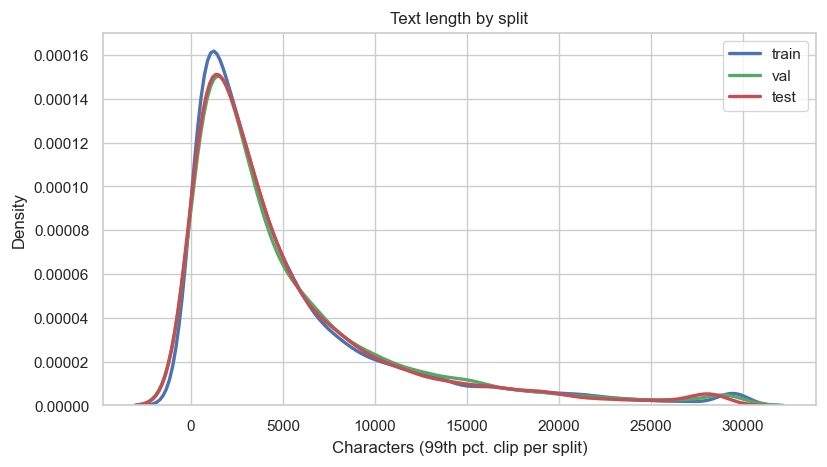

/var/folders/hh/cj64t6m14sd46vthykgl9lwc0000gn/T/ipykernel_97187/1221296504.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x="supercategory", y="n_chars", order=sc_ord, ax=ax2, palette="pastel")


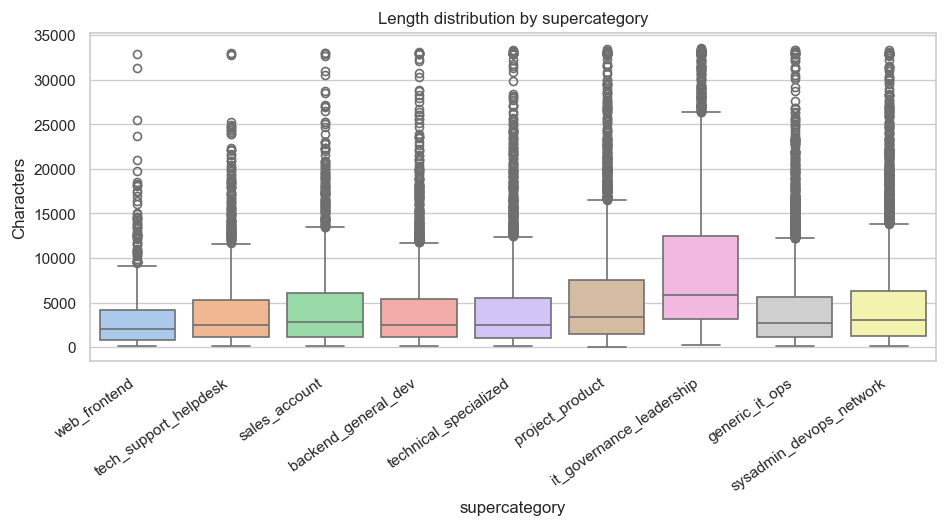

**Interpretation.** Length varies by job family; aggressive truncation can drop tail content. Length may correlate with geography or template style—candidate confounder for both accuracy and spurious cues.

In [6]:
text = df_all["resume_text"].fillna("").astype(str)
df_all["n_chars"] = text.str.len()
df_all["n_words"] = text.str.split().str.len()

df_all.groupby("split").agg(
    mean_chars=("n_chars", "mean"),
    median_chars=("n_chars", "median"),
    p90_chars=("n_chars", lambda s: float(np.percentile(s, 90))),
    mean_words=("n_words", "mean"),
).to_csv(RESULTS_DIR / "07_text_length_by_split.csv")

fig, ax = plt.subplots(figsize=(7, 4))
for sp, color in zip(["train", "val", "test"], ["#4c72b0", "#55a868", "#c44e52"]):
    subset = df_all.loc[df_all["split"] == sp, "n_chars"]
    cap = float(np.percentile(subset, 99))
    sns.kdeplot(subset.clip(upper=cap), ax=ax, label=sp, color=color, lw=2)
ax.set_xlabel("Characters (99th pct. clip per split)")
ax.set_title("Text length by split")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "07_text_length_kde_by_split.png")
plt.show()

sc_ord = sc_total.index.tolist()
fig2, ax2 = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=df_all, x="supercategory", y="n_chars", order=sc_ord, ax=ax2, palette="pastel")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=35, ha="right")
ax2.set_ylabel("Characters")
ax2.set_title("Length distribution by supercategory")
fig2.tight_layout()
fig2.savefig(FIG_DIR / "08_text_length_by_supercategory.png")
plt.show()

display(
    Markdown(
        "**Interpretation.** Length varies by job family; aggressive truncation can drop tail content. "
        "Length may correlate with geography or template style—candidate confounder for both accuracy and spurious cues."
    )
)


## 6. Duplicates and template-like structure


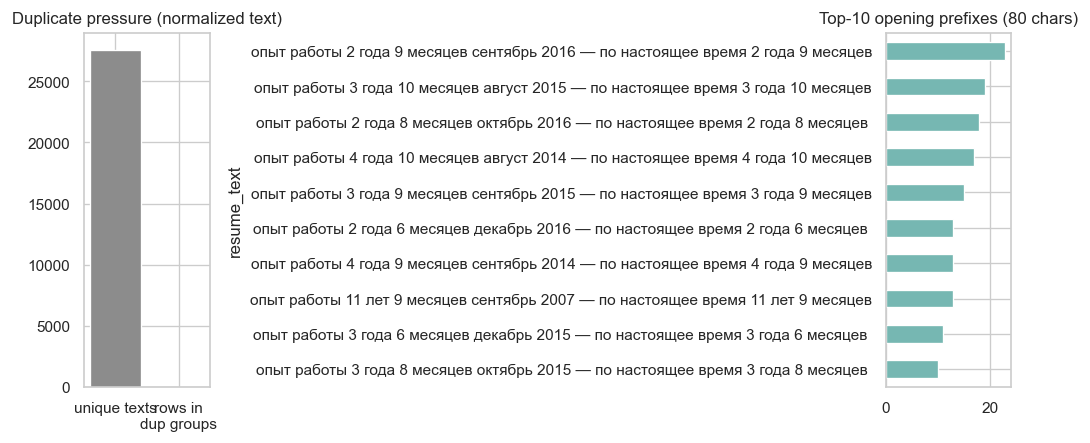

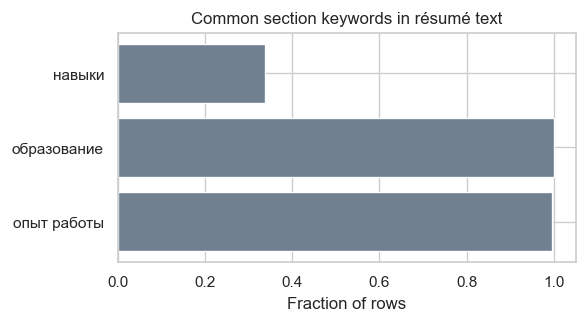

**Interpretation.** **0.04%** of rows share normalized text with at least one other row. **99.6%** begin with the standard HeadHunter experience header. Shared section keywords are ubiquitous—models can exploit **format** rather than competence.

In [7]:
norm_text = text.map(normalize_ws)
dup_mask = norm_text.duplicated(keep=False)

pd.DataFrame(
    {
        "metric": [
            "n_rows",
            "unique_normalized_text",
            "rows_in_duplicate_groups",
            "frac_rows_in_duplicate_groups",
        ],
        "value": [
            len(df_all),
            int(norm_text.nunique()),
            int(dup_mask.sum()),
            float(dup_mask.mean()),
        ],
    }
).to_csv(RESULTS_DIR / "09_duplicates_summary.csv", index=False)

prefix = norm_text.str.slice(0, 80)
prefix.value_counts().head(30).to_csv(RESULTS_DIR / "09_top_text_prefixes.csv")

starts_exp = float(text.str.startswith("Опыт работы", na=False).mean())

fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.8))
axes[0].bar(
    ["unique texts", "rows in\ndup groups"],
    [norm_text.nunique(), int(dup_mask.sum())],
    color=["#8c8c8c", "#b07aa1"],
)
axes[0].set_title("Duplicate pressure (normalized text)")
prefix_counts = prefix.value_counts().head(10).sort_values()
prefix_counts.plot(kind="barh", ax=axes[1], color="#76b7b2")
axes[1].set_title("Top-10 opening prefixes (80 chars)")
fig.tight_layout()
fig.savefig(FIG_DIR / "09_duplicates_and_prefixes.png")
plt.show()

template_phrases = {
    "опыт работы": text.str.contains("опыт работы", case=False, na=False).mean(),
    "образование": text.str.contains("образование", case=False, na=False).mean(),
    "навыки": text.str.contains("навыки", case=False, na=False).mean(),
}
pd.Series(template_phrases).to_csv(RESULTS_DIR / "09_template_phrase_rates.csv", header=["frac"])

fig2, ax2 = plt.subplots(figsize=(5, 2.8))
ax2.barh(list(template_phrases.keys()), list(template_phrases.values()), color="slategray")
ax2.set_xlabel("Fraction of rows")
ax2.set_title("Common section keywords in résumé text")
fig2.tight_layout()
fig2.savefig(FIG_DIR / "09_template_keyword_rates.png")
plt.show()

display(
    Markdown(
        f"**Interpretation.** **{dup_mask.mean():.2%}** of rows share normalized text with at least one other row. "
        f"**{starts_exp:.1%}** begin with the standard HeadHunter experience header. Shared section keywords are ubiquitous—models can exploit **format** rather than competence."
    )
)


## 7. Proxy correlations and simple leakage cues


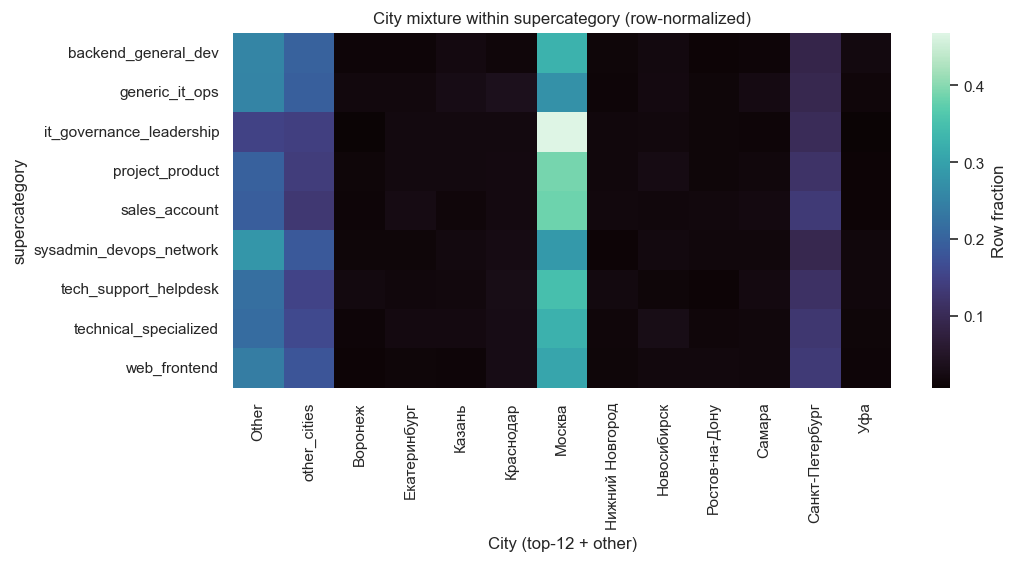

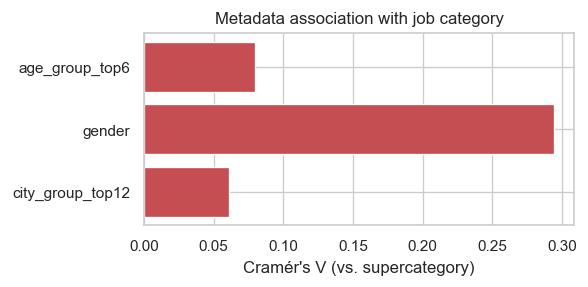

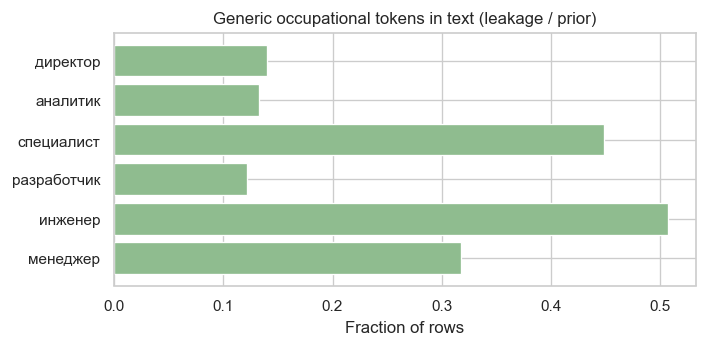

**Interpretation.** Non-zero Cramér's V indicates **statistical dependence** between metadata and target category—shortcuts for unconstrained classifiers. The row-normalized city heatmap shows **different geographic priors per supercategory**, motivating **city-swap** stress tests. **68.1%** of rows embed the full fine `label` substring in the body (template / leakage); **83.1%** of non-`Other` city rows mention the city string in text.

In [8]:
city_collapsed = collapse_rare_categories(df_all["city_group"], 12, "other_cities")
rows_v = []
for name, ser in [
    ("city_group_top12", city_collapsed),
    ("gender", df_all["gender"]),
    ("age_group_top6", collapse_rare_categories(df_all["age_group"], 6, "other_age")),
]:
    tab = pd.crosstab(df_all["supercategory"], ser)
    rows_v.append({"attribute": name, "cramers_v_with_supercategory": cramers_v(tab)})

cv_df = pd.DataFrame(rows_v)
cv_df.to_csv(RESULTS_DIR / "10_cramers_v_supercategory.csv", index=False)

tab_city = pd.crosstab(df_all["supercategory"], city_collapsed)
chi2, p_city, _, _ = chi2_contingency(tab_city, correction=False)
prop = tab_city.div(tab_city.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(9, 4.8))
sns.heatmap(prop, cmap="mako", ax=ax, cbar_kws={"label": "Row fraction"})
ax.set_title("City mixture within supercategory (row-normalized)")
ax.set_xlabel("City (top-12 + other)")
fig.tight_layout()
fig.savefig(FIG_DIR / "10_supercat_city_mixture.png")
plt.show()

fig2, ax2 = plt.subplots(figsize=(5, 2.5))
ax2.barh(cv_df["attribute"], cv_df["cramers_v_with_supercategory"], color="#c44e52")
ax2.set_xlabel("Cramér's V (vs. supercategory)")
ax2.set_title("Metadata association with job category")
fig2.tight_layout()
fig2.savefig(FIG_DIR / "10_cramers_v_bar.png")
plt.show()

lb_norm = df_all["label"].fillna("").map(normalize_ws)
rt_norm = df_all["resume_text"].fillna("").map(normalize_ws)
label_sub_arr = np.fromiter(
    ((len(l) >= 6 and (l in r)) for l, r in zip(lb_norm, rt_norm)),
    dtype=bool,
    count=len(df_all),
)
df_all["label_substring_in_text"] = label_sub_arr

cg_s = df_all["city_group"].astype(str)
rt_lower = df_all["resume_text"].astype(str).str.lower()
city_sub = np.fromiter(
    ((c not in ("Other", "nan") and bool(c) and c.lower() in t) for c, t in zip(cg_s, rt_lower)),
    dtype=bool,
    count=len(df_all),
)
df_all["city_name_in_text"] = city_sub

_non_other = df_all["city_group"].astype(str) != "Other"
_frac_city = (
    float(df_all.loc[_non_other, "city_name_in_text"].mean()) if bool(_non_other.any()) else float("nan")
)

pd.DataFrame({"frac_rows": df_all.groupby("supercategory")["label_substring_in_text"].mean()}).to_csv(
    RESULTS_DIR / "11_label_substring_rate_by_supercategory.csv"
)

pd.DataFrame(
    {
        "metric": ["frac_label_substring_in_text", "frac_city_name_in_text_non_other"],
        "value": [float(df_all["label_substring_in_text"].mean()), _frac_city],
    }
).to_csv(RESULTS_DIR / "11_text_leakage_proxies.csv", index=False)

# Label-token overlap: share of common job tokens in text vs label (coarse proxy)
common_tokens = ["менеджер", "инженер", "разработчик", "специалист", "аналитик", "директор"]
tok_rates = {tok: float(text.str.contains(tok, case=False, na=False).mean()) for tok in common_tokens}
pd.Series(tok_rates).to_csv(RESULTS_DIR / "11_common_job_token_rates.csv", header=["frac"])

fig3, ax3 = plt.subplots(figsize=(6, 3))
ax3.barh(list(tok_rates.keys()), list(tok_rates.values()), color="darkseagreen")
ax3.set_xlabel("Fraction of rows")
ax3.set_title("Generic occupational tokens in text (leakage / prior)")
fig3.tight_layout()
fig3.savefig(FIG_DIR / "11_common_token_rates.png")
plt.show()

display(
    Markdown(
        f"**Interpretation.** Non-zero Cramér's V indicates **statistical dependence** between metadata and target category—shortcuts for unconstrained classifiers. "
        f"The row-normalized city heatmap shows **different geographic priors per supercategory**, motivating **city-swap** stress tests. "
        f"**{df_all['label_substring_in_text'].mean():.1%}** of rows embed the full fine `label` substring in the body (template / leakage); "
        f"**{_frac_city:.1%}** of non-`Other` city rows mention the city string in text."
    )
)


## 8. Run manifest (machine-readable summary)


In [9]:
manifest = {
    "repo_root": str(REPO_ROOT),
    "n_total": int(len(df_all)),
    "splits": split_counts.astype(int).to_dict(),
    "n_supercategories": int(df_all["supercategory"].nunique()),
    "n_fine_labels": int(df_all["label"].nunique()),
    "imbalance_supercat_max_over_min": float(imb_sc),
    "duplicate_row_frac": float(dup_mask.mean()),
    "unknown_age_frac": unknown_age_frac,
    "moscow_frac": moscow_frac,
    "frac_label_substring_in_text": float(df_all["label_substring_in_text"].mean()),
    "frac_city_name_in_text_non_other": float(_frac_city) if _frac_city == _frac_city else None,
    "cramers_v": cv_df.set_index("attribute")["cramers_v_with_supercategory"].round(4).to_dict(),
    "chi2_supercat_x_collapsed_city_p_value": float(p_city),
}

with open(RESULTS_DIR / "audit_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

print("Wrote", RESULTS_DIR / "audit_manifest.json")


Wrote /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/notebooks/results/dataset_audit/audit_manifest.json


## 9. Paper-facing conclusions


In [10]:
with open(RESULTS_DIR / "audit_manifest.json", "r", encoding="utf-8") as f:
    M = json.load(f)

_cv_items = ", ".join(
    f"`{k}`={v:.3f}" for k, v in sorted(M["cramers_v"].items(), key=lambda kv: kv[0])
)
takeaway_md = f"""
## Key takeaways

1. **Scale & supervision** — **{M["n_total"]:,}** labeled résumés; **{M["n_supercategories"]}** BERT supercategories from **{M["n_fine_labels"]}** fine titles. Splits: **{M["splits"]["train"]:,} / {M["splits"]["val"]:,} / {M["splits"]["test"]:,}**.

2. **Imbalance** — Supercategory imbalance (max/min **{M["imbalance_supercat_max_over_min"]:.2f}**) plus a long tail of titles motivates reweighting, focal loss, and GroupDRO (`20_*`–`29_*`, `challengers/`).

3. **Geography & fairness** — Moscow share **{M["moscow_frac"]:.1%}**; metadata–label associations ({_cv_items}) and shifting city mixtures by class justify **group metrics**, **intersectional checks**, and **city-swap** evaluation (`70_*`–`73_*`).

4. **Templates & attribution** — Duplicate / boilerplate pressure (**{M["duplicate_row_frac"]:.1%}** rows in duplicate normalized-text groups) and **{M["frac_label_substring_in_text"]:.1%}** with fine title embedded in text motivate **Integrated Gradients** (`41_*`) and **attribution regularization** (`63_*`) to limit reliance on spurious spans.

5. **Missing age** — **{M["unknown_age_frac"]:.1%}** `Unknown` age—report age gaps with caution.

_All audit tables and figures: `notebooks/results/dataset_audit/`, `figures/dataset_audit/`._
"""
display(Markdown(takeaway_md))



## Key takeaways

1. **Scale & supervision** — **27,550** labeled résumés; **9** BERT supercategories from **125** fine titles. Splits: **16,530 / 5,510 / 5,510**.

2. **Imbalance** — Supercategory imbalance (max/min **5.49**) plus a long tail of titles motivates reweighting, focal loss, and GroupDRO (`20_*`–`29_*`, `challengers/`).

3. **Geography & fairness** — Moscow share **33.9%**; metadata–label associations (`age_group_top6`=0.080, `city_group_top12`=0.061, `gender`=0.294) and shifting city mixtures by class justify **group metrics**, **intersectional checks**, and **city-swap** evaluation (`70_*`–`73_*`).

4. **Templates & attribution** — Duplicate / boilerplate pressure (**0.0%** rows in duplicate normalized-text groups) and **68.1%** with fine title embedded in text motivate **Integrated Gradients** (`41_*`) and **attribution regularization** (`63_*`) to limit reliance on spurious spans.

5. **Missing age** — **40.8%** `Unknown` age—report age gaps with caution.

_All audit tables and figures: `notebooks/results/dataset_audit/`, `figures/dataset_audit/`._
